In [1]:
import numpy as np
import matplotlib.pyplot as plt
import OptimalBattery.util as ut
import os
import PcmPy as pcm
import seaborn as sns
import pandas as pd
import OptimalBattery.evaluate as ev
import Functional_Fusion.atlas_map as am
from Functional_Fusion.dataset import DataSetMDTB
from IndividualParcellation.global_config import *
import nilearn.plotting as plotting
import nitools as nt
import nibabel as nb
import OptimalBattery.estimate as es
import OptimalBattery.construct as ct
import OptimalBattery.plot as plot


Default device set to: cuda


# define atlas and dirs

In [2]:
space = 'fs32k'
atlas,_= am.get_atlas(atlas_str=space)
base_dir = 'Y:/data/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/'

func_fus_dir = os.path.join(base_dir, 'FunctionalFusion')
cerebellum_dir = os.path.join(base_dir, 'Cerebellum')

In [3]:
  # Load surface files for left and right hemispheres
surfs = [f"{func_fus_dir}/Atlases/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii" for h in ['L', 'R']]
def plot_cortex(data, threshold=0.0, cmap='binary', figsize=(12, 6)):  

    # Convert data to CIFTI format
    cifti = atlas.data_to_cifti(data)
    
    # Extract data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)
    
    # Create the plot
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=figsize)
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap=cmap,
            axes=axes[h],
            threshold=threshold,
            title=f'figure {h+1}'
        )
    
    return fig

In [4]:
# Load glasser atlas
# roi (prefrontal cortex)
atlas_dir = f'{func_fus_dir}/Atlases/tpl-fs32k'
model_name_L = f'{atlas_dir}/glasser.L.label.gii'
model_name_R = f'{atlas_dir}/glasser.R.label.gii'
glasser_atlas = atlas.read_data([model_name_L,model_name_R])


In [5]:
# define PFC parcel and get the indices of the PFC parcels
PFC_parcels = [
    "10pp", "10r", "10d", "10v", "a10p", "p10p", "OFC", "pOFC",
    "11l", "13l", "25", "p32", "a32pr", "s32", "p24", "a24",
     "47m", "47s"
]

# Load the GIFTI file
gifti_data = nb.load(model_name_L)
parcel_names = [label.label for label in gifti_data.labeltable.labels]
parcel_names = [name[len("L_"):] if name.startswith("L_") else name for name in parcel_names]
parcel_names = [name[:-len("_ROI")] if name.endswith("_ROI") else name for name in parcel_names]

# Get the indices of the PFC parcels
ROI_cortex = []
for name in PFC_parcels:
    ROI_cortex.append(parcel_names.index(name))


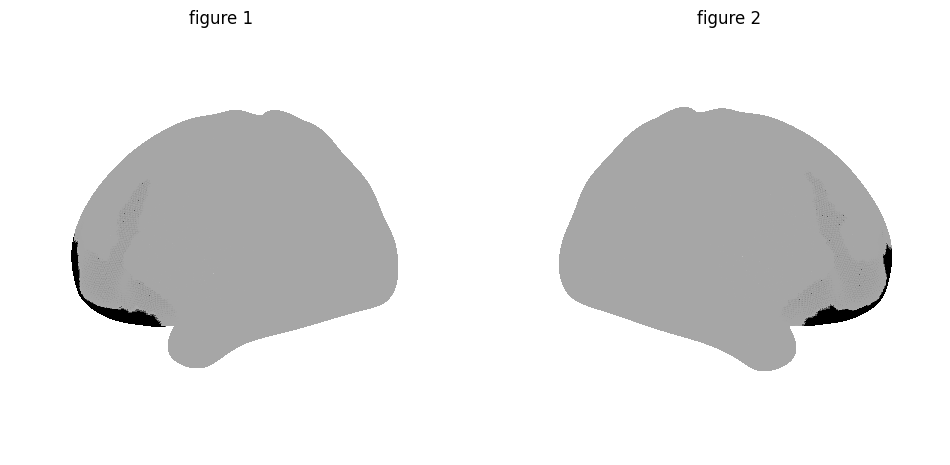

4009

In [6]:
# make mask for PFC and plot 
ROI_mask = np.isin(glasser_atlas, ROI_cortex).astype(int)
mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

fig = plot_cortex(mask_reshaped, threshold=0.1, cmap='binary', figsize=(12, 6))
plt.show()

# find indices where mask is 1 
ROI_indices = np.where(ROI_mask == 1)[0]
len(ROI_indices)

# Load data

- mdtb_1 - run: Data used to make libray of tasks and to use task batteries for parcellations
- mdtb_1 - all: Data used to pick the Vs of the top parcels
- mdtb_2 - all: Data used to test parcellation predicition error

In [7]:
MDTB_dataset = DataSetMDTB(f'{func_fus_dir}/MDTB')


data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s1_all,info_mdtb_1_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
data_mdtb_s1_all[np.isnan(data_mdtb_s1_all)] = 0



data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


recenter data around rest so that the variance in the Glibrary is signal compared to rest  
centers each row around the rest in its run and remove the rest row from each run


In [8]:
data_mdtb_s1_run = ut.recenter_fmri_data(data_mdtb_s1_run,info_mdtb_1_run,task_column_name='cond_name',center_condition='rest')
data_mdtb_s1_all = ut.recenter_fmri_data(data_mdtb_s1_all,info_mdtb_1_all,task_column_name='cond_name',center_condition='rest')


# Get crossvalidated second moment matrix (GLib)

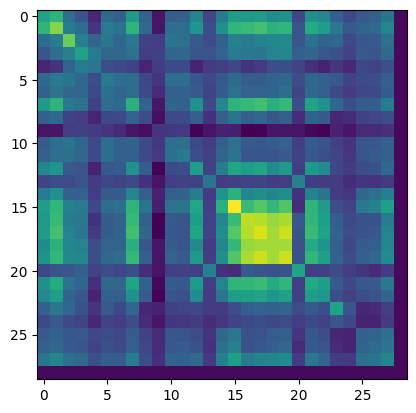

In [9]:
cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)
Gs_list = []
E_list = []
for i in range(data_mdtb_s1_run.shape[0]):
    Gs,E = pcm.util.est_G_crossval(data_mdtb_s1_run[i][:,ROI_indices] , cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_Lib = np.mean(Gs_list, axis=0)

plt.imshow(G_Lib, cmap='viridis')

# Build dataframes with different task battery size (n_tasks) and different number of parcels (n_parcels) and evaluate

In [10]:
# make variables torch
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
data_mdtb_s1_all = pt.tensor(data_mdtb_s1_all, dtype=pt.float32, device=device)
data_test = pt.tensor(data_mdtb_s2_all, dtype=pt.float32, device=device)
data_train = pt.tensor(data_mdtb_s1_run, dtype=pt.float32, device=device)
parcelation = pt.tensor(glasser_atlas, dtype=pt.float32, device=device)
ROI_mask = pt.tensor(ROI_mask, dtype=pt.float32, device=device)


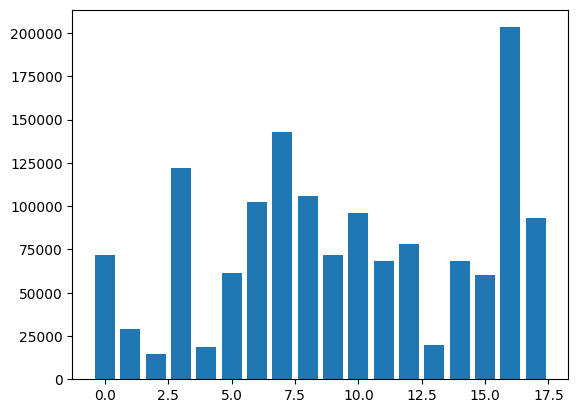

In [11]:
# estimate Vs for session 1 using s1 full data
full_vs_train = es.estimate_Vs(data_mdtb_s1_all,parcellation=parcelation,ROI_mask= ROI_mask)
full_vs_train = ut.center_matrix(full_vs_train,axis=0)
full_vs_train = ut.normalize_matrix(full_vs_train,axis=0)

# estimate Vs for session 2 using s2 full data
full_vs_test = es.estimate_Vs(data_test,parcellation=parcelation,ROI_mask=ROI_mask)
full_vs_test = ut.center_matrix(full_vs_test,axis=0)
full_vs_test = ut.normalize_matrix(full_vs_test,axis=0)

# Get list of parcels ordered by size by counting voxel assignments across subjects (using Vs from session 1)
Us = es.estimate_Us(data_mdtb_s1_all, full_vs_train,method='correlation',hard=True)
parcel_counts = Us.sum(dim=(0,2))
sorted_parcels = pt.argsort(parcel_counts, descending=True).cpu().numpy()
parcel_counts = parcel_counts.cpu().numpy()
total_parcels = len(sorted_parcels)

plt.bar(range(len(parcel_counts)), parcel_counts)
plt.show()

In [12]:
condition_df= ct.get_condition_indices(info_mdtb_1_run)

In [13]:
battery_sizes = [3,4,5,6,7,8,10,14,16]
# parcel_sizes = [2,4,6,8,10,16,total_parcels]

parcel_sizes = [8,15,total_parcels]
# battery_sizes = [4,6]

In [14]:
results_df = pd.DataFrame()
for n_parcel in parcel_sizes:
    print(f"Processing parcel size: {n_parcel}")
    parcel_indices = sorted_parcels[:n_parcel]
    VLib = full_vs_train[:,parcel_indices]
    Vtest = full_vs_test[:,parcel_indices]
    for n_task in battery_sizes:
        print(f"Processing battery size: {n_task}")
        # Generate possible battery combinations for current battery size and calculate eigenmetrics
        D = ct.build_combinations(G_Lib, strategy='random',n_batteries=10000,n_tasks=n_task,seed=1,replacement=False,rest_idx=28)
        D_ev = ev.evluate_dataframe( D = D, condition_df= condition_df, YLib= data_train,
                                     VLib= VLib, Ytest= data_test, Vtest= Vtest,indices=ROI_indices,method='correlation')

        D_ev['n_parcel'] = n_parcel
        D_ev['n_task'] = n_task

        results_df = pd.concat([results_df, D_ev], ignore_index=True)
    


Processing parcel size: 8
Processing battery size: 3
Processing combination: 0
Processing battery size: 4
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing battery size: 5
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing battery size: 6
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing combination: 6000
Processing combination: 7000
Processing combination: 8000
Processing combination: 9000
Processing battery size: 7
Processing combination: 0
Processing combination: 1000
Processing combination: 2000
Processing combination: 3000
Processing combination: 4000
Processing combination: 5000
Processing co

In [12]:
name = os.path.join(base_dir, 'OptimalBattery','Eval_tsvs', 'cortex-PFC_MDTB_ses-01_ses-02_results_correlation.tsv')

# save to tsv
# results_df.to_csv(name, sep="\t", index=False)

#load
results_df = pd.read_csv(name, sep="\t")

# Make proposal sets (sampling with repelcament from the batteries evaluated) for each n_tasks and n_parcels

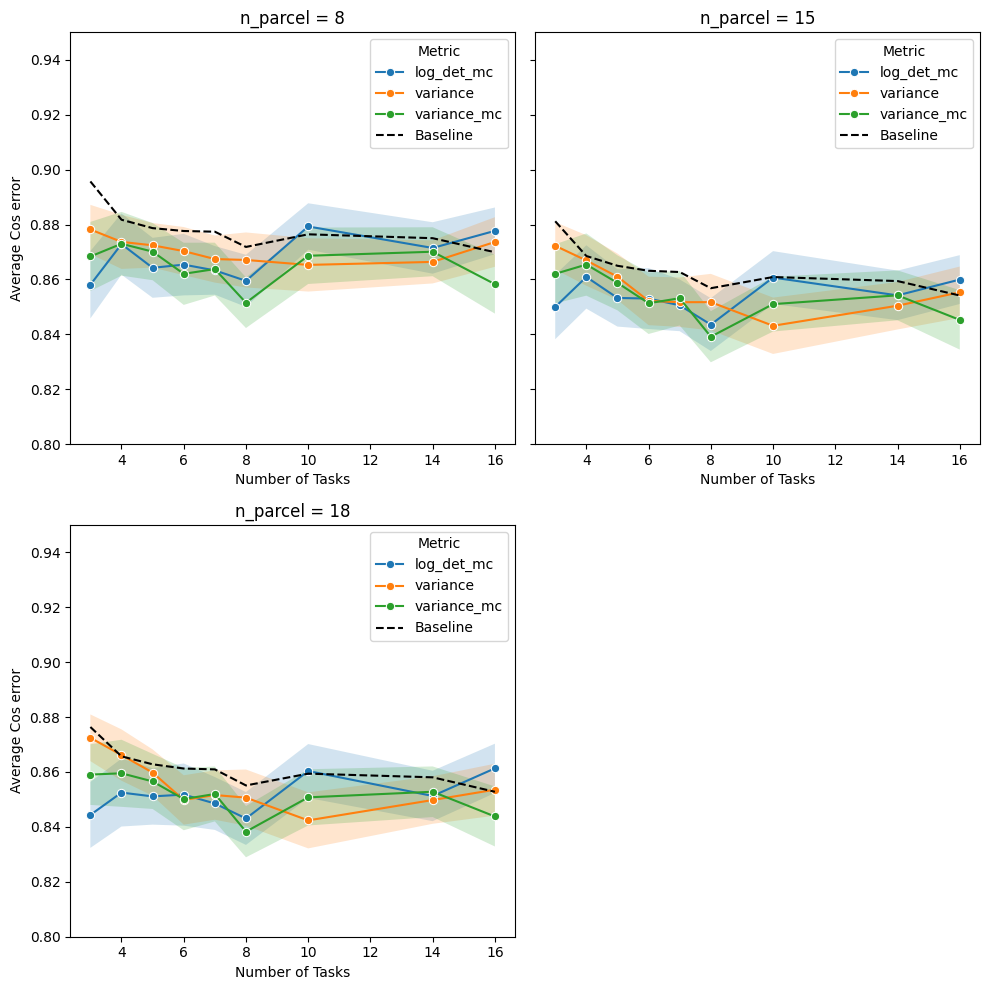

In [13]:
metrics = ["variance", "variance_mc", "log_det_mc"]
n_proposal_sets = 100
resampled_results_df = plot.resample_df(results_df, metrics, n_proposal_sets)
expanded_results_df = plot.expand_subject_results(resampled_results_df)
aggregated_results_df = plot.compute_aggregated_results(expanded_results_df)
baseline_aggregated_df = plot.compute_baseline(results_df)
plot.plot_results(aggregated_results_df, baseline_aggregated_df,y_min=0.8, y_max=0.95)